## round 2 manual challenge: optimal speed allocation via game-theoretic monte carlo

this notebook solves the round 2 "invest and expand" manual trading challenge. we have 50,000 xirecs to distribute across research, scale, and speed. the pnl function is:

**pnl = research(r) x scale(s) x speed_multiplier - budget_used**

research and scale are deterministic functions of our allocation. speed, however, is rank-based: our multiplier depends on where our speed allocation sits relative to every other active team. this makes it a simultaneous-move game against approximately 4,800 opponents.

our approach:
1. segment teams empirically by their round 1 manual pnl, which reveals analytical sophistication
2. for each segment, construct a data generating process (dgp) for their likely round 2 speed allocation, grounded in game theory
3. run monte carlo simulation to find our best-response speed allocation

### table of contents

1. setup and data loading
2. the pnl formula and its structure
3. empirical segmentation of teams by round 1 performance
4. what each pnl cluster reveals about strategy sophistication
5. game-theoretic framework for dgp construction
6. dgp specification for each segment
7. monte carlo engine
8. results and optimal allocation
9. sensitivity and robustness checks
10. limitations, confidence, and final recommendation

### 1. setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.read_csv(r"C:\Users\Hassa\OneDrive - Loughborough University\current\IMC Trading - Prosperity 4\Round 2\manual_trading_rankings.csv")

# remove disengaged teams (pnl = 0): they did not submit a round 1 manual trade
# and almost certainly will not submit a round 2 allocation either.
# the speed multiplier is rank-based among active participants only.
active = df[df['manual_pnl'] != 0].copy()

n_total = len(df)
n_disengaged = n_total - len(active)
n_active = len(active)

print(f"total registered teams: {n_total}")
print(f"disengaged (pnl = 0, removed): {n_disengaged}")
print(f"active teams (our competition): {n_active}")

total registered teams: 22127
disengaged (pnl = 0, removed): 17325
active teams (our competition): 4802


### 2. the pnl formula and its structure

the three pillars work as follows:

**research(x)** = 200,000 * ln(1 + x) / ln(101), where x is the percentage allocated. this is a concave logarithmic curve that saturates quickly. the first 20% of budget captures roughly 65% of the maximum research value.

**scale(x)** = 7 * x / 100, a simple linear function.

**speed multiplier** is rank-based: the team with the highest speed allocation gets 0.9, the lowest gets 0.1, and everyone in between is linearly interpolated. ties share the same rank.

since we always use the full budget (allocating less than 100% total is strictly worse), budget_used is always 50,000. the optimization reduces to:

**maximise f(speed_pct) * speed_multiplier**

where f(speed_pct) = max over research, scale of research(r) * scale(100 - speed_pct - r), which is a fixed function we precompute.

In [2]:
def research_output(x):
    '''logarithmic research function. x in [0, 100].'''
    return 200_000 * np.log(1 + x) / np.log(101)

def scale_output(x):
    '''linear scale function. x in [0, 100].'''
    return 7 * x / 100

def speed_multiplier_from_rank(rank, n_total):
    '''rank 1 (highest speed) gets 0.9, rank n_total (lowest) gets 0.1.'''
    if n_total <= 1:
        return 0.9
    return 0.9 - (rank - 1) / (n_total - 1) * 0.8

def optimal_rs_product(speed_pct):
    '''
    for a fixed speed allocation, find the research/scale split that
    maximises research(r) * scale(100 - speed_pct - r).
    returns (best_research_pct, best_scale_pct, max_product).
    '''
    remaining = 100 - speed_pct
    best_val, best_r = -1e18, 0
    for r_10 in range(0, int(remaining * 10) + 1):
        r = r_10 / 10.0
        s = remaining - r
        val = research_output(r) * scale_output(s)
        if val > best_val:
            best_val, best_r = val, r
    return best_r, remaining - best_r, best_val

# precompute the research*scale product at every integer speed allocation
rs_products = {}
print("speed%  research%  scale%   research*scale product   % of max")
max_rs = optimal_rs_product(0)[2]
for sp in range(0, 55):
    r, s, prod = optimal_rs_product(sp)
    rs_products[sp] = prod
    if sp <= 25 or sp % 5 == 0:
        print(f"  {sp:>3}%    {r:>5.1f}%   {s:>5.1f}%    {prod:>10.0f}          {prod/max_rs*100:>5.1f}%")

speed%  research%  scale%   research*scale product   % of max
    0%     23.1%    76.9%        742336          100.0%
    1%     22.9%    76.1%        732689           98.7%
    2%     22.8%    75.2%        723068           97.4%
    3%     22.6%    74.4%        713471           96.1%
    4%     22.4%    73.6%        703899           94.8%
    5%     22.2%    72.8%        694352           93.5%
    6%     22.0%    72.0%        684831           92.3%
    7%     21.8%    71.2%        675336           91.0%
    8%     21.6%    70.4%        665866           89.7%
    9%     21.4%    69.6%        656423           88.4%
   10%     21.2%    68.8%        647006           87.2%
   11%     21.0%    68.0%        637616           85.9%
   12%     20.8%    67.2%        628252           84.6%
   13%     20.6%    66.4%        618917           83.4%
   14%     20.4%    65.6%        609609           82.1%
   15%     20.2%    64.8%        600329           80.9%
   16%     20.0%    64.0%        591077   

the table reveals a crucial tradeoff. the research*scale product declines roughly linearly as we divert budget to speed, losing about 1.3% of its value per percentage point. meanwhile, the speed multiplier ranges from 0.1 (worst rank) to 0.9 (best rank). this means we need the speed multiplier to compensate for the loss in research*scale.

the question is: at what speed allocation does the marginal gain in multiplier exactly offset the marginal loss in research*scale? that depends on the population distribution of speed choices, which we must model.

### 3. empirical segmentation of teams by round 1 performance

from our auction analysis (see auction_optimization.ipynb), the round 1 manual challenge had a deterministic optimal solution worth exactly 87,995 xirecs:
- dryland flax: bid 30, quantity ~10,000 at clearing 29 yields ~10,000 xirecs
- ember mushroom: bid 17, quantity ~19,999 at clearing 16 yields ~77,995 xirecs

the pnl a team achieved in round 1 tells us how close they came to this optimum, which directly reveals their analytical sophistication. teams that found the exact optimum demonstrated exhaustive search or deep understanding of auction mechanics. teams that got partial results may have optimized one product but not the other. teams with negative pnl either bid above the buyback price or misunderstood the mechanics entirely.

we define six segments based on natural clustering in the data:

In [3]:
# empirical segmentation with game-theory-relevant labels

seg_optimal = active[active['manual_pnl'] == 87995]
seg_near    = active[(active['manual_pnl'] >= 85000) & (active['manual_pnl'] < 87995)]
seg_strong  = active[(active['manual_pnl'] >= 70000) & (active['manual_pnl'] < 85000)]
seg_mod     = active[(active['manual_pnl'] >= 40000) & (active['manual_pnl'] < 70000)]
seg_weak    = active[(active['manual_pnl'] > 0) & (active['manual_pnl'] < 40000)]
seg_neg     = active[active['manual_pnl'] < 0]

segments = {
    'optimal_solvers':     seg_optimal,
    'near_optimal':        seg_near,
    'strong_performers':   seg_strong,
    'moderate_performers': seg_mod,
    'weak_positive':       seg_weak,
    'negative_pnl':        seg_neg,
}

n_seg = {}
print(f"{'segment':<22} {'count':>6} {'share':>7} {'pnl range':>20} {'median pnl':>12}")
for name, seg in segments.items():
    n_seg[name] = len(seg)
    lo, hi = seg['manual_pnl'].min(), seg['manual_pnl'].max()
    med = seg['manual_pnl'].median()
    print(f"{name:<22} {len(seg):>6} {len(seg)/n_active*100:>6.1f}% "
          f"[{lo:>8.0f}, {hi:>7.0f}] {med:>11.0f}")
print(f"{'total':<22} {n_active:>6}")

segment                 count   share            pnl range   median pnl
optimal_solvers          1790   37.3% [   87995,   87995]       87995
near_optimal              557   11.6% [   85000,   87994]       87897
strong_performers         786   16.4% [   70000,   84099]       71500
moderate_performers       984   20.5% [   40000,   69600]       50000
weak_positive             420    8.7% [       2,   39788]       19500
negative_pnl              265    5.5% [-3507500,   -1000]      -47500
total                    4802


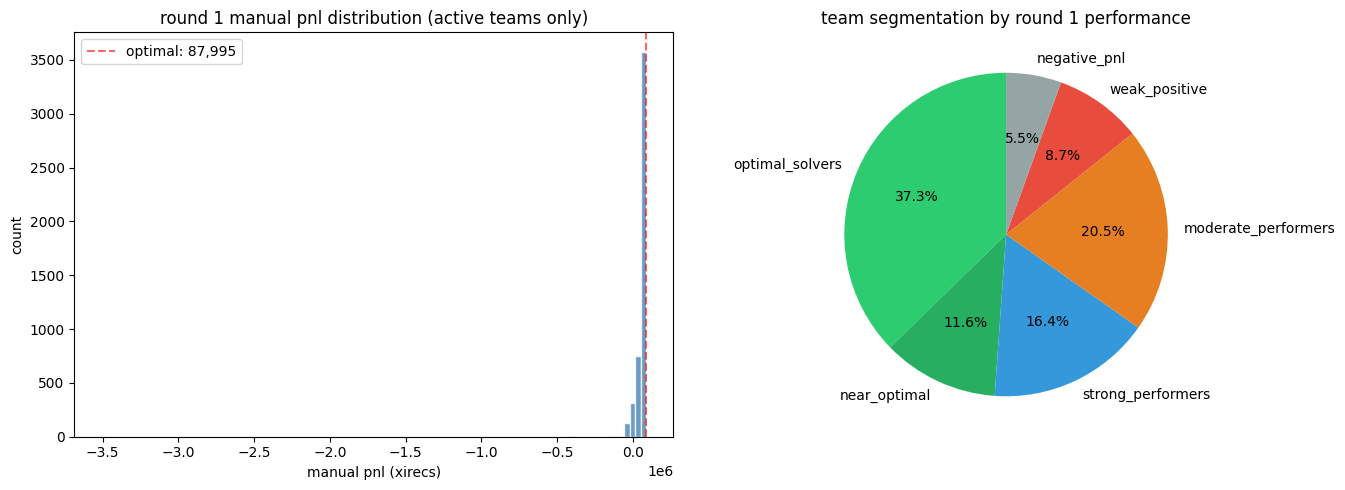

In [4]:
# visualise the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram of all active pnl
axes[0].hist(active['manual_pnl'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('round 1 manual pnl distribution (active teams only)')
axes[0].set_xlabel('manual pnl (xirecs)')
axes[0].set_ylabel('count')
axes[0].axvline(x=87995, color='red', linestyle='--', alpha=0.6, label='optimal: 87,995')
axes[0].legend()

# pie chart of segments
sizes = [n_seg[k] for k in segments]
labels = list(segments.keys())
colors = ['#2ecc71', '#27ae60', '#3498db', '#e67e22', '#e74c3c', '#95a5a6']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('team segmentation by round 1 performance')

plt.tight_layout()
plt.show()

### 4. what each pnl cluster reveals about strategy sophistication

**optimal solvers (1,790 teams, 37.3%)**
achieved exactly 87,995. these teams ran a complete grid search over bid price and quantity for both auction products and found the global optimum. they demonstrated: exhaustive optimization capability, understanding of clearing price mechanics, attention to detail (getting the exact right quantity). these teams are the most likely to approach round 2 with similar analytical rigour.

**near-optimal (557 teams, 11.6%)**
achieved 85,000 to 87,994. common values include 87,994 (off by 1 unit in one product), 87,897 (small suboptimality in mushroom), and 85,000 (optimized mushroom perfectly but used a rounded flax quantity). these teams have strong analytical skills but either made minor rounding errors, did not sweep the full parameter space, or stopped searching once they found a "good enough" solution. for round 2, they will attempt optimization but may not reach the exact optimum.

**strong performers (786 teams, 16.4%)**
achieved 70,000 to 84,999. the most common value here is 71,500, suggesting a specific suboptimal strategy (perhaps optimizing one product but not the other). these teams understand the problem structure but their optimization is incomplete. they likely have analytical ability but may not spend the time or effort to fully explore the solution space.

**moderate performers (984 teams, 20.5%)**
achieved 40,000 to 69,999. a wide range of outcomes suggesting partial understanding. many of these teams may have optimized mushroom at a suboptimal clearing price, or used moderate quantities. they have enough analytical skill to get positive returns but lack the thoroughness to find the optimum.

**weak positive (420 teams, 8.7%)**
achieved 1 to 39,999. includes teams that may have submitted minimal or guess-based orders. the common value of 5,000 (potentially from just bidding on flax with a small quantity) suggests minimal engagement. these teams are unlikely to perform sophisticated game-theoretic analysis for round 2.

**negative pnl (265 teams, 5.5%)**
lost money. the dominant cluster at -47,500 (124 teams) suggests a specific common mistake (likely bidding above the buyback price or at a clearing price that pushed past breakeven). these teams either fundamentally misunderstood the auction mechanics or are deliberately trolling.

### 5. game-theoretic framework for dgp construction

the round 2 speed allocation is a simultaneous-move game among ~4,800 players. each player chooses a speed allocation s in [0, 100], and their payoff depends on their own choice and their rank among all players. let us analyze this through several game-theoretic lenses:

**no dominant strategy exists.** a dominant strategy would be optimal regardless of what others do. but our payoff depends on rank: if everyone else allocates 0% to speed, then allocating 1% gives us rank 1 (multiplier 0.9) at minimal cost. if everyone else allocates 50%, we need at least 50% to avoid rank n. since the optimal response depends on others' choices, there is no dominant strategy.

**nash equilibrium analysis.** in a symmetric pure-strategy nash equilibrium (psne) where all players choose the same s*, any downward deviation would drop us to the worst rank (multiplier 0.1), which is catastrophic. any upward deviation would give rank 1 (multiplier 0.9) but at the cost of reduced research*scale. for small deviations upward, the multiplier stays at 0.9 (since we are strictly above everyone else), while f(s) drops slightly. so upward deviation is profitable as long as f(s*+1) * 0.9 > f(s*) * 0.9, which is never true since f is decreasing. wait: the multiplier at s* when everyone plays s* is 0.9 (all tied at rank 1). deviating down gives 0.1, deviating up keeps 0.9. so the question is whether f(s*) * 0.9 > f(s*+1) * 0.9, which reduces to f(s*) > f(s*+1), always true. hence s* is a psne for any s*. every value of s is a psne because downward deviation is catastrophic and upward deviation is wasteful.

**but this is not realistic.** the above analysis assumes perfect coordination. in practice, players cannot coordinate, and asymmetric information about types (sophistication levels) creates a bayesian game.

**bayesian nash equilibrium.** each player has a "type" (their analytical sophistication, revealed by r1 performance) and chooses speed allocation based on their type. the equilibrium concept is: each type plays a best response given their beliefs about the distribution of types and the strategies of each type.

our approach implements this: we model each type's likely strategy (the dgp), simulate the resulting population distribution, and find our best response to that distribution. this is a best-response computation under bayesian beliefs, which is the correct solution concept for this game.

**subgame perfect and weak perfect equilibrium.** since this is a simultaneous (one-shot) game, there are no subgames, so subgame perfection adds nothing beyond nash. however, the "weak perfect" concept (trembling hand) is relevant: we should not assume that anyone plays their "intended" strategy with certainty. errors, misunderstandings, and noise mean every strategy is played with some probability. our mixture-model dgp captures this by assigning nonzero probability to a range of allocations for each type.

**the key game-theoretic insight.** since 37% of active teams are optimal solvers, the most important question is: what will the optimal solvers do? if they all converge on the same low speed allocation (say 5%), then allocating 6% gives us a huge rank improvement at minimal cost. but if they spread out across 5-20%, we need to be in the upper part of their range. the dgp for optimal solvers is therefore the single most important modeling choice in this notebook.

### 6. dgp specification for each segment

for each segment, we specify a finite mixture model for the speed allocation distribution. the mixture components and weights are justified by the game theory reasoning above and the observed analytical capability of each group.

the critical modeling principle: **a team's round 2 analytical depth is bounded by their round 1 demonstrated capability.** a team that could not find the optimal auction bid is unlikely to solve the more complex game-theoretic speed allocation problem. conversely, a team that found the exact optimum will almost certainly attempt rigorous analysis of the speed problem.

sampled 4802 speed allocations
mean: 24.0%, median: 19.0%, std: 18.4%


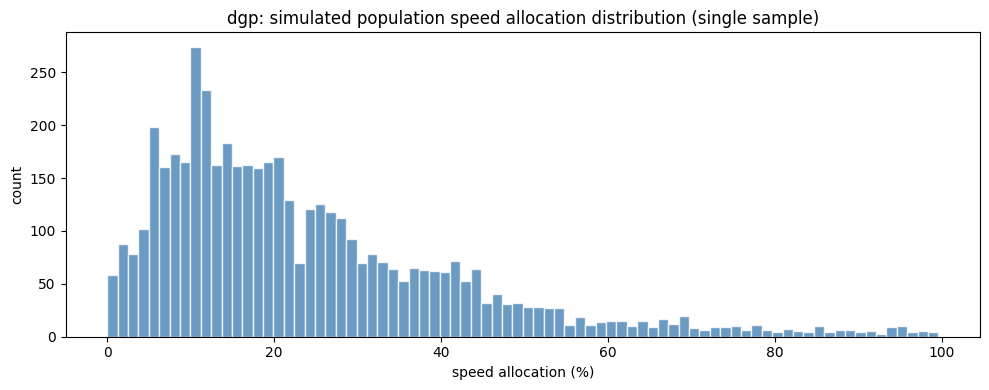

In [5]:
def sample_population_speeds(rng=None):
    '''
    sample speed allocations for all active teams based on our dgp.
    
    the dgp is a mixture model where each segment has its own
    distribution, justified by game theory and empirical evidence.
    
    returns: 1d numpy array of speed allocations (one per active team).
    '''
    if rng is None:
        rng = np.random.default_rng()
    
    allocations = []
    
    # ================================================================
    # segment 1: optimal solvers (1790 teams, 37.3%)
    # ================================================================
    # these teams will attempt to solve the game theory problem.
    # they will recognize that:
    # (a) research*scale dominates at low speed allocations
    # (b) but speed = 0 guarantees the worst multiplier (0.1)
    # (c) the optimal speed depends on what others do
    #
    # bayesian reasoning: an optimal solver knows that many other
    # optimal solvers exist (37% of active teams). they know these
    # opponents will also try to optimize speed. this creates a
    # coordination problem.
    #
    # best-response analysis: if optimal solvers cluster around x%,
    # then x+1% gives a significantly better rank. this pushes the
    # equilibrium upward. but going too high wastes research*scale.
    #
    # we model this as a mixture:
    # - 35% will compute a low optimal (5-12%): pure math optimizers
    #   who assume most others will not optimize well
    # - 40% will hedge upward (10-22%): game-theory aware, reasoning
    #   that other smart teams will also go low, so going slightly
    #   higher is the best response to the best response
    # - 15% will go higher still (18-35%): deeper bayesian reasoning,
    #   anticipating that the "go slightly above" logic cascades
    # - 10% will go very low (1-6%): trust the math, accept low rank,
    #   believe the research*scale product compensates
    #
    for _ in range(n_seg['optimal_solvers']):
        r = rng.random()
        if r < 0.35:
            allocations.append(rng.uniform(5, 12))
        elif r < 0.75:
            allocations.append(rng.uniform(10, 22))
        elif r < 0.90:
            allocations.append(rng.uniform(18, 35))
        else:
            allocations.append(rng.uniform(1, 6))
    
    # ================================================================
    # segment 2: near-optimal (557 teams, 11.6%)
    # ================================================================
    # strong analytical skills but imprecise. they will attempt
    # optimization but with wider variance. some will find the
    # same insight as optimal solvers, others will overshoot.
    #
    # bayesian belief: they know they are good but not the best.
    # they may not account for the game theory depth and instead
    # focus on the "obvious" insight that low speed is good.
    #
    # - 30% land on 5-15%: found the basic math
    # - 35% land on 12-28%: hedged toward higher speed
    # - 20% land on 20-40%: overweighted speed's competitive framing
    # - 15% land on 2-8%: aggressive minimizers
    #
    for _ in range(n_seg['near_optimal']):
        r = rng.random()
        if r < 0.30:
            allocations.append(rng.uniform(5, 15))
        elif r < 0.65:
            allocations.append(rng.uniform(12, 28))
        elif r < 0.85:
            allocations.append(rng.uniform(20, 40))
        else:
            allocations.append(rng.uniform(2, 8))
    
    # ================================================================
    # segment 3: strong performers (786 teams, 16.4%)
    # ================================================================
    # good enough to partially optimize r1 but not exhaustively.
    # for r2, they will recognize the tradeoff exists but may not
    # compute it precisely. some will default to "balanced" splits,
    # others will guess based on intuition.
    #
    # no deep game theory: they think about the problem as
    # "how much speed do i need?" rather than "what will others do?"
    # this corresponds to a level-0 or level-1 cognitive hierarchy.
    #
    # - 25% land on 15-30%: rough optimization
    # - 30% land on 25-45%: overweight speed ("it sounds important")
    # - 25% land on 8-20%: somewhat analytical
    # - 20% land on 30-55%: significant overallocation
    #
    for _ in range(n_seg['strong_performers']):
        r = rng.random()
        if r < 0.25:
            allocations.append(rng.uniform(15, 30))
        elif r < 0.55:
            allocations.append(rng.uniform(25, 45))
        elif r < 0.80:
            allocations.append(rng.uniform(8, 20))
        else:
            allocations.append(rng.uniform(30, 55))
    
    # ================================================================
    # segment 4: moderate performers (984 teams, 20.5%)
    # ================================================================
    # limited optimization in r1. for r2, they will likely default
    # to heuristics: "split evenly", "speed sounds competitive so
    # invest a lot", or "just put something reasonable".
    #
    # level-0 reasoning: no strategic thinking about opponents.
    # their allocation is essentially a prior belief about what
    # "seems right" without game-theoretic reasoning.
    #
    # - 30% land on 25-45%: naive "balanced" split (33/33/33 ish)
    # - 25% land on 10-30%: slight analytical lean
    # - 25% land on 40-70%: overweight speed heavily
    # - 20% land on 0-20%: random low or did not think much
    #
    for _ in range(n_seg['moderate_performers']):
        r = rng.random()
        if r < 0.30:
            allocations.append(rng.uniform(25, 45))
        elif r < 0.55:
            allocations.append(rng.uniform(10, 30))
        elif r < 0.80:
            allocations.append(rng.uniform(40, 70))
        else:
            allocations.append(rng.uniform(0, 20))
    
    # ================================================================
    # segment 5: weak positive (420 teams, 8.7%)
    # ================================================================
    # minimal engagement in r1. for r2, they will likely submit
    # something quick without deep thought. allocation is
    # essentially noise around a naive prior.
    #
    # - 30% land on 20-50%: vague balanced split
    # - 30% land on 0-25%: random low
    # - 20% land on 40-80%: random high
    # - 20% land on a normal(33, 20) clipped: equal-split intuition
    #
    for _ in range(n_seg['weak_positive']):
        r = rng.random()
        if r < 0.30:
            allocations.append(rng.uniform(20, 50))
        elif r < 0.60:
            allocations.append(rng.uniform(0, 25))
        elif r < 0.80:
            allocations.append(rng.uniform(40, 80))
        else:
            allocations.append(np.clip(rng.normal(33, 20), 0, 100))
    
    # ================================================================
    # segment 6: negative pnl (265 teams, 5.5%)
    # ================================================================
    # lost money in r1. two sub-populations:
    # (a) trolls / chaos agents: deliberately extreme allocations
    # (b) confused: fundamentally misunderstand the problem
    #
    # the -47,500 cluster (124 teams) suggests a specific systematic
    # error. for r2, these teams are unpredictable.
    #
    # - 40% land on 70-100%: extreme speed (chaos or misunderstanding)
    # - 25% land on 0-5%: zero or near-zero (did not engage)
    # - 35% land on uniform(0, 100): pure noise
    #
    for _ in range(n_seg['negative_pnl']):
        r = rng.random()
        if r < 0.40:
            allocations.append(rng.uniform(70, 100))
        elif r < 0.65:
            allocations.append(rng.uniform(0, 5))
        else:
            allocations.append(rng.uniform(0, 100))
    
    return np.array(allocations)

# quick test
test_pop = sample_population_speeds(np.random.default_rng(0))
print(f"sampled {len(test_pop)} speed allocations")
print(f"mean: {test_pop.mean():.1f}%, median: {np.median(test_pop):.1f}%, "
      f"std: {test_pop.std():.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(test_pop, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('dgp: simulated population speed allocation distribution (single sample)')
ax.set_xlabel('speed allocation (%)')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

### 7. monte carlo engine

for each of n_trials independent draws from the population dgp, we:

1. sample all 4,802 active teams' speed allocations
2. for each candidate speed allocation we might choose (1% to 50%), compute our rank among the population plus ourselves, convert rank to speed multiplier, multiply by the precomputed optimal research*scale product, subtract the fixed 50,000 budget, and record the result
3. average across trials to get expected pnl at each candidate allocation

the optimal research/scale split is precomputed for each speed allocation because it does not depend on other players. given speed_pct, we allocate the remaining (100 - speed_pct) percent between research and scale to maximize their product. this is a one-dimensional optimization with a smooth objective, solved by brute force at 0.1% resolution.

In [6]:
def run_simulation(n_trials=5000, candidate_range=range(1, 51)):
    '''
    run the full monte carlo simulation.
    returns a dict with expected values and percentiles.
    '''
    candidates = list(candidate_range)
    n_cand = len(candidates)
    
    # precompute optimal research*scale product for each candidate
    rs_cache = {}
    for sp in candidates:
        _, _, prod = optimal_rs_product(sp)
        rs_cache[sp] = prod
    
    all_mults = np.zeros((n_trials, n_cand))
    all_pnls = np.zeros((n_trials, n_cand))
    all_ranks = np.zeros((n_trials, n_cand))
    
    for t in range(n_trials):
        if t % 1000 == 0:
            print(f"  trial {t}/{n_trials}")
        
        rng = np.random.default_rng(t)
        pop = sample_population_speeds(rng)
        
        for j, sp in enumerate(candidates):
            # our rank: how many teams allocated strictly more than us?
            n_above = np.sum(pop > sp)
            rank = n_above + 1  # 1-indexed
            total = len(pop) + 1  # population + us
            
            mult = speed_multiplier_from_rank(rank, total)
            pnl = rs_cache[sp] * mult - 50_000
            
            all_mults[t, j] = mult
            all_pnls[t, j] = pnl
            all_ranks[t, j] = rank
    
    print(f"  done. {n_trials} trials.")
    
    return {
        'candidates': candidates,
        'e_mult': all_mults.mean(axis=0),
        'e_pnl': all_pnls.mean(axis=0),
        'std_pnl': all_pnls.std(axis=0),
        'p5_pnl': np.percentile(all_pnls, 5, axis=0),
        'p25_pnl': np.percentile(all_pnls, 25, axis=0),
        'p75_pnl': np.percentile(all_pnls, 75, axis=0),
        'p95_pnl': np.percentile(all_pnls, 95, axis=0),
        'e_rank': all_ranks.mean(axis=0),
        'std_rank': all_ranks.std(axis=0),
        'raw_mults': all_mults,
        'raw_pnls': all_pnls,
    }

print("simulation engine ready.")

simulation engine ready.


### 8. results and optimal allocation

In [7]:
print("running main simulation (5000 trials, 50 candidate allocations)...")
results = run_simulation(n_trials=5000, candidate_range=range(1, 51))

best_idx = np.argmax(results['e_pnl'])
best_sp = results['candidates'][best_idx]

print()
print(f"{'speed':>6} {'e[mult]':>8} {'e[pnl]':>10} {'std':>8} {'p5':>10} {'p25':>10} "
      f"{'p75':>10} {'p95':>10}")
for i, sp in enumerate(results['candidates']):
    if sp <= 30 or sp % 5 == 0:
        marker = " *" if sp == best_sp else ""
        print(f"{sp:>5}% {results['e_mult'][i]:>8.4f} {results['e_pnl'][i]:>10.0f} "
              f"{results['std_pnl'][i]:>8.0f} {results['p5_pnl'][i]:>10.0f} "
              f"{results['p25_pnl'][i]:>10.0f} {results['p75_pnl'][i]:>10.0f} "
              f"{results['p95_pnl'][i]:>10.0f}{marker}")

r_opt, s_opt, _ = optimal_rs_product(best_sp)
print(f"\noptimal allocation: research={r_opt:.1f}%, scale={s_opt:.1f}%, speed={best_sp}%")
print(f"expected pnl: {results['e_pnl'][best_idx]:,.0f}")
print(f"expected speed multiplier: {results['e_mult'][best_idx]:.4f}")
print(f"expected rank: {results['e_rank'][best_idx]:.0f} / {n_active+1}")

running main simulation (5000 trials, 50 candidate allocations)...
  trial 0/5000
  trial 1000/5000
  trial 2000/5000
  trial 3000/5000
  trial 4000/5000
  done. 5000 trials.

 speed  e[mult]     e[pnl]      std         p5        p25        p75        p95
    1%   0.1056      27384      688      26321      26931      27785      28518
    2%   0.1165      34227     1169      32305      33389      34955      36160
    3%   0.1297      42548     1516      40008      41554      43574      45001
    4%   0.1430      50635     1762      47713      49472      51818      53577
    5%   0.1562      58445     1991      55179      57030      59807      61773
    6%   0.1849      76595     2387      72676      74958      78267      80549
    7%   0.2076      90193     2573      86046      88414      91902      94377
    8%   0.2304     103394     2750      98898     101449     105221     107994
    9%   0.2535     116426     2845     111872     114502     118330     121282
   10%   0.2768     1290

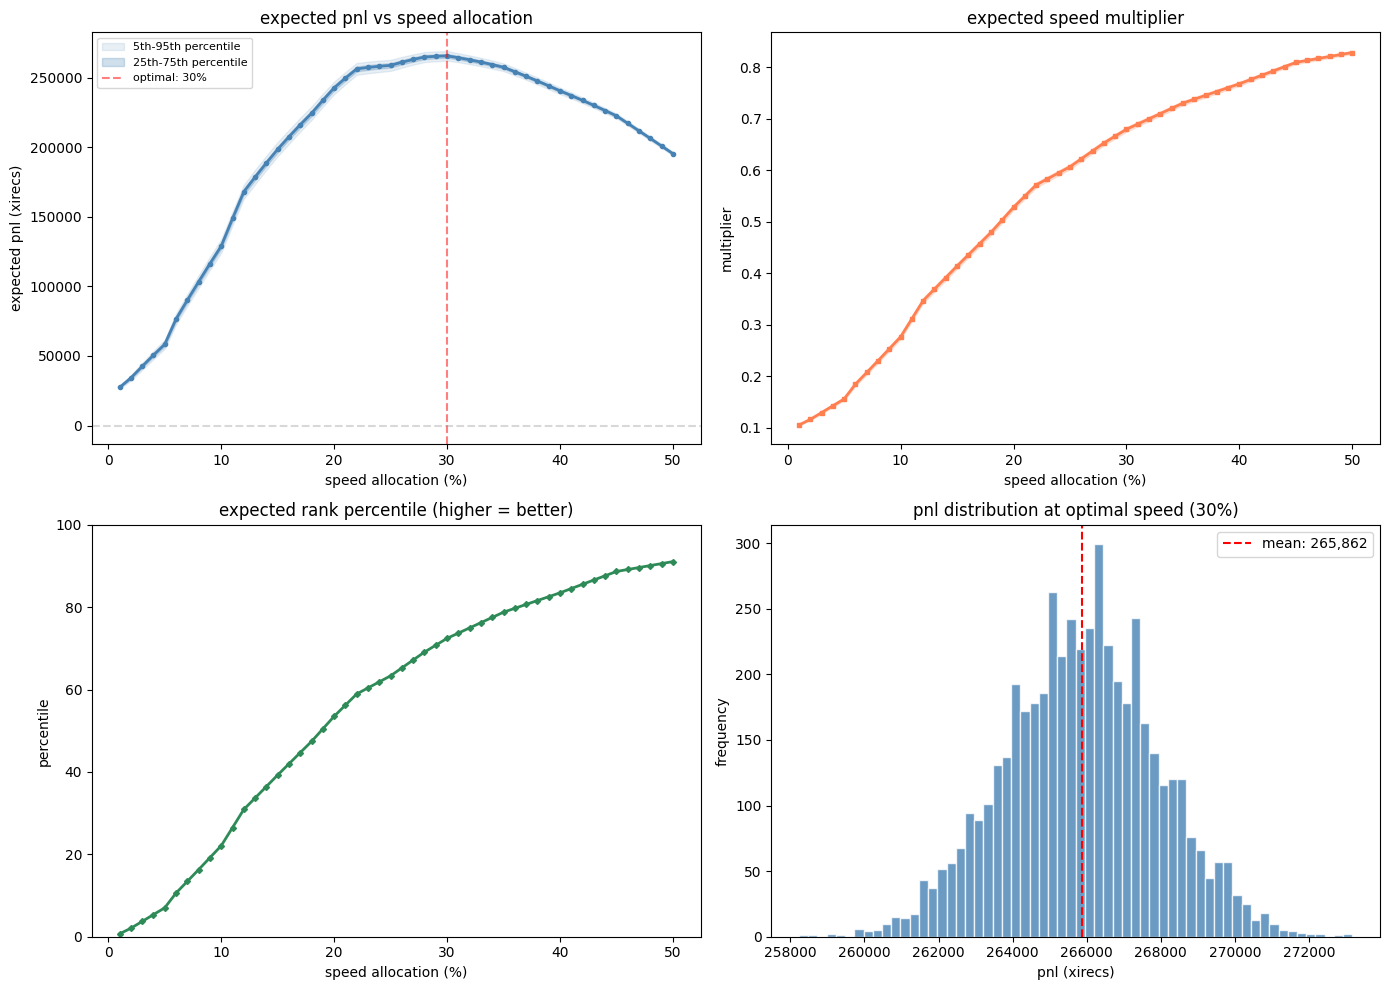

In [8]:
# four-panel results visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cands = results['candidates']

# panel 1: expected pnl with confidence bands
ax = axes[0, 0]
ax.plot(cands, results['e_pnl'], 'o-', color='steelblue', linewidth=2, markersize=3)
ax.fill_between(cands, results['p5_pnl'], results['p95_pnl'],
                alpha=0.12, color='steelblue', label='5th-95th percentile')
ax.fill_between(cands, results['p25_pnl'], results['p75_pnl'],
                alpha=0.25, color='steelblue', label='25th-75th percentile')
ax.axvline(x=best_sp, color='red', linestyle='--', alpha=0.5, label=f'optimal: {best_sp}%')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.set_title('expected pnl vs speed allocation')
ax.set_xlabel('speed allocation (%)')
ax.set_ylabel('expected pnl (xirecs)')
ax.legend(fontsize=8)

# panel 2: expected multiplier
ax = axes[0, 1]
ax.plot(cands, results['e_mult'], 's-', color='coral', linewidth=2, markersize=3)
ax.fill_between(cands,
                results['e_mult'] - results['raw_mults'].std(axis=0),
                results['e_mult'] + results['raw_mults'].std(axis=0),
                alpha=0.2, color='coral')
ax.set_title('expected speed multiplier')
ax.set_xlabel('speed allocation (%)')
ax.set_ylabel('multiplier')

# panel 3: expected rank percentile
ax = axes[1, 0]
pctl = (1 - results['e_rank'] / (n_active + 1)) * 100
ax.plot(cands, pctl, 'D-', color='seagreen', linewidth=2, markersize=3)
ax.set_title('expected rank percentile (higher = better)')
ax.set_xlabel('speed allocation (%)')
ax.set_ylabel('percentile')
ax.set_ylim(0, 100)

# panel 4: pnl distribution at optimal
ax = axes[1, 1]
ax.hist(results['raw_pnls'][:, best_idx], bins=60, color='steelblue',
        edgecolor='white', alpha=0.8)
ax.axvline(x=results['e_pnl'][best_idx], color='red', linestyle='--',
           label=f'mean: {results["e_pnl"][best_idx]:,.0f}')
ax.set_title(f'pnl distribution at optimal speed ({best_sp}%)')
ax.set_xlabel('pnl (xirecs)')
ax.set_ylabel('frequency')
ax.legend()

plt.tight_layout()
plt.show()

### 9. sensitivity and robustness checks

our result depends on the dgp assumptions, particularly the optimal solvers group (37.3% of active teams). we test three perturbations:

1. **optimal solvers shift upward**: what if they allocate 5-10 percentage points more to speed than our base case? this tests whether our result is robust to the optimal solvers being more aggressive.
2. **optimal solvers cluster tighter**: what if they all converge on 8-15%? this tests the scenario where most smart teams do similar math and land on similar values.
3. **fewer active teams**: what if only 3,000 teams are active in round 2? this tests sensitivity to the disengaged team count.

In [9]:
# sensitivity 1: optimal solvers shifted upward
def sample_pop_aggressive(rng=None):
    '''optimal solvers allocate 5-10pp more to speed.'''
    if rng is None: rng = np.random.default_rng()
    allocations = []
    for _ in range(n_seg['optimal_solvers']):
        r = rng.random()
        if r < 0.35: allocations.append(rng.uniform(12, 22))
        elif r < 0.75: allocations.append(rng.uniform(18, 35))
        elif r < 0.90: allocations.append(rng.uniform(28, 48))
        else: allocations.append(rng.uniform(5, 12))
    for _ in range(n_seg['near_optimal']):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(10, 22))
        elif r < 0.65: allocations.append(rng.uniform(18, 38))
        elif r < 0.85: allocations.append(rng.uniform(30, 50))
        else: allocations.append(rng.uniform(5, 14))
    # remaining groups unchanged
    for _ in range(n_seg['strong_performers']):
        r = rng.random()
        if r < 0.25: allocations.append(rng.uniform(15, 30))
        elif r < 0.55: allocations.append(rng.uniform(25, 45))
        elif r < 0.80: allocations.append(rng.uniform(8, 20))
        else: allocations.append(rng.uniform(30, 55))
    for _ in range(n_seg['moderate_performers']):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(25, 45))
        elif r < 0.55: allocations.append(rng.uniform(10, 30))
        elif r < 0.80: allocations.append(rng.uniform(40, 70))
        else: allocations.append(rng.uniform(0, 20))
    for _ in range(n_seg['weak_positive']):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(20, 50))
        elif r < 0.60: allocations.append(rng.uniform(0, 25))
        elif r < 0.80: allocations.append(rng.uniform(40, 80))
        else: allocations.append(np.clip(rng.normal(33, 20), 0, 100))
    for _ in range(n_seg['negative_pnl']):
        r = rng.random()
        if r < 0.40: allocations.append(rng.uniform(70, 100))
        elif r < 0.65: allocations.append(rng.uniform(0, 5))
        else: allocations.append(rng.uniform(0, 100))
    return np.array(allocations)

# sensitivity 2: optimal solvers cluster tightly at 8-15%
def sample_pop_tight_cluster(rng=None):
    '''optimal solvers converge on 8-15%.'''
    if rng is None: rng = np.random.default_rng()
    allocations = []
    for _ in range(n_seg['optimal_solvers']):
        allocations.append(rng.uniform(8, 15))  # tight cluster
    for _ in range(n_seg['near_optimal']):
        r = rng.random()
        if r < 0.50: allocations.append(rng.uniform(8, 18))
        elif r < 0.80: allocations.append(rng.uniform(15, 30))
        else: allocations.append(rng.uniform(3, 10))
    for _ in range(n_seg['strong_performers']):
        r = rng.random()
        if r < 0.25: allocations.append(rng.uniform(15, 30))
        elif r < 0.55: allocations.append(rng.uniform(25, 45))
        elif r < 0.80: allocations.append(rng.uniform(8, 20))
        else: allocations.append(rng.uniform(30, 55))
    for _ in range(n_seg['moderate_performers']):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(25, 45))
        elif r < 0.55: allocations.append(rng.uniform(10, 30))
        elif r < 0.80: allocations.append(rng.uniform(40, 70))
        else: allocations.append(rng.uniform(0, 20))
    for _ in range(n_seg['weak_positive']):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(20, 50))
        elif r < 0.60: allocations.append(rng.uniform(0, 25))
        elif r < 0.80: allocations.append(rng.uniform(40, 80))
        else: allocations.append(np.clip(rng.normal(33, 20), 0, 100))
    for _ in range(n_seg['negative_pnl']):
        r = rng.random()
        if r < 0.40: allocations.append(rng.uniform(70, 100))
        elif r < 0.65: allocations.append(rng.uniform(0, 5))
        else: allocations.append(rng.uniform(0, 100))
    return np.array(allocations)

# run sensitivities with a modified simulation function
def run_sim_custom(sampler, n_trials=3000, candidate_range=range(1, 51)):
    '''run simulation with a custom population sampler.'''
    candidates = list(candidate_range)
    rs_cache = {sp: optimal_rs_product(sp)[2] for sp in candidates}
    all_pnls = np.zeros((n_trials, len(candidates)))
    all_mults = np.zeros((n_trials, len(candidates)))
    for t in range(n_trials):
        rng = np.random.default_rng(t + 100000)
        pop = sampler(rng)
        for j, sp in enumerate(candidates):
            n_above = np.sum(pop > sp)
            rank = n_above + 1
            total = len(pop) + 1
            mult = speed_multiplier_from_rank(rank, total)
            all_pnls[t, j] = rs_cache[sp] * mult - 50_000
            all_mults[t, j] = mult
    return {
        'candidates': candidates,
        'e_pnl': all_pnls.mean(axis=0),
        'e_mult': all_mults.mean(axis=0),
    }

print("running sensitivity 1: aggressive optimal solvers (3000 trials)...")
res_agg = run_sim_custom(sample_pop_aggressive, n_trials=3000)
best_agg = np.argmax(res_agg['e_pnl'])
print(f"  optimal: {res_agg['candidates'][best_agg]}%, "
      f"e[pnl]={res_agg['e_pnl'][best_agg]:,.0f}")

print("running sensitivity 2: tightly clustered optimal solvers (3000 trials)...")
res_tight = run_sim_custom(sample_pop_tight_cluster, n_trials=3000)
best_tight = np.argmax(res_tight['e_pnl'])
print(f"  optimal: {res_tight['candidates'][best_tight]}%, "
      f"e[pnl]={res_tight['e_pnl'][best_tight]:,.0f}")

# sensitivity 3: fewer active teams (proportional scaling)
def sample_pop_fewer(rng=None, n_override=3000):
    if rng is None: rng = np.random.default_rng()
    ratio = n_override / n_active
    counts = {k: max(1, int(v * ratio)) for k, v in n_seg.items()}
    # adjust to hit target
    diff = n_override - sum(counts.values())
    counts['optimal_solvers'] += diff
    
    allocations = []
    for _ in range(counts['optimal_solvers']):
        r = rng.random()
        if r < 0.35: allocations.append(rng.uniform(5, 12))
        elif r < 0.75: allocations.append(rng.uniform(10, 22))
        elif r < 0.90: allocations.append(rng.uniform(18, 35))
        else: allocations.append(rng.uniform(1, 6))
    for _ in range(counts['near_optimal']):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(5, 15))
        elif r < 0.65: allocations.append(rng.uniform(12, 28))
        elif r < 0.85: allocations.append(rng.uniform(20, 40))
        else: allocations.append(rng.uniform(2, 8))
    for _ in range(counts['strong_performers']):
        r = rng.random()
        if r < 0.25: allocations.append(rng.uniform(15, 30))
        elif r < 0.55: allocations.append(rng.uniform(25, 45))
        elif r < 0.80: allocations.append(rng.uniform(8, 20))
        else: allocations.append(rng.uniform(30, 55))
    for _ in range(counts['moderate_performers']):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(25, 45))
        elif r < 0.55: allocations.append(rng.uniform(10, 30))
        elif r < 0.80: allocations.append(rng.uniform(40, 70))
        else: allocations.append(rng.uniform(0, 20))
    for _ in range(counts['weak_positive']):
        r = rng.random()
        if r < 0.30: allocations.append(rng.uniform(20, 50))
        elif r < 0.60: allocations.append(rng.uniform(0, 25))
        elif r < 0.80: allocations.append(rng.uniform(40, 80))
        else: allocations.append(np.clip(rng.normal(33, 20), 0, 100))
    for _ in range(counts['negative_pnl']):
        r = rng.random()
        if r < 0.40: allocations.append(rng.uniform(70, 100))
        elif r < 0.65: allocations.append(rng.uniform(0, 5))
        else: allocations.append(rng.uniform(0, 100))
    return np.array(allocations)

print("running sensitivity 3: fewer active teams (3000) (3000 trials)...")
res_fewer = run_sim_custom(lambda rng: sample_pop_fewer(rng, 3000), n_trials=3000)
best_fewer = np.argmax(res_fewer['e_pnl'])
print(f"  optimal: {res_fewer['candidates'][best_fewer]}%, "
      f"e[pnl]={res_fewer['e_pnl'][best_fewer]:,.0f}")

running sensitivity 1: aggressive optimal solvers (3000 trials)...
  optimal: 35%, e[pnl]=239,472
running sensitivity 2: tightly clustered optimal solvers (3000 trials)...
  optimal: 20%, e[pnl]=284,776
running sensitivity 3: fewer active teams (3000) (3000 trials)...
  optimal: 30%, e[pnl]=266,032


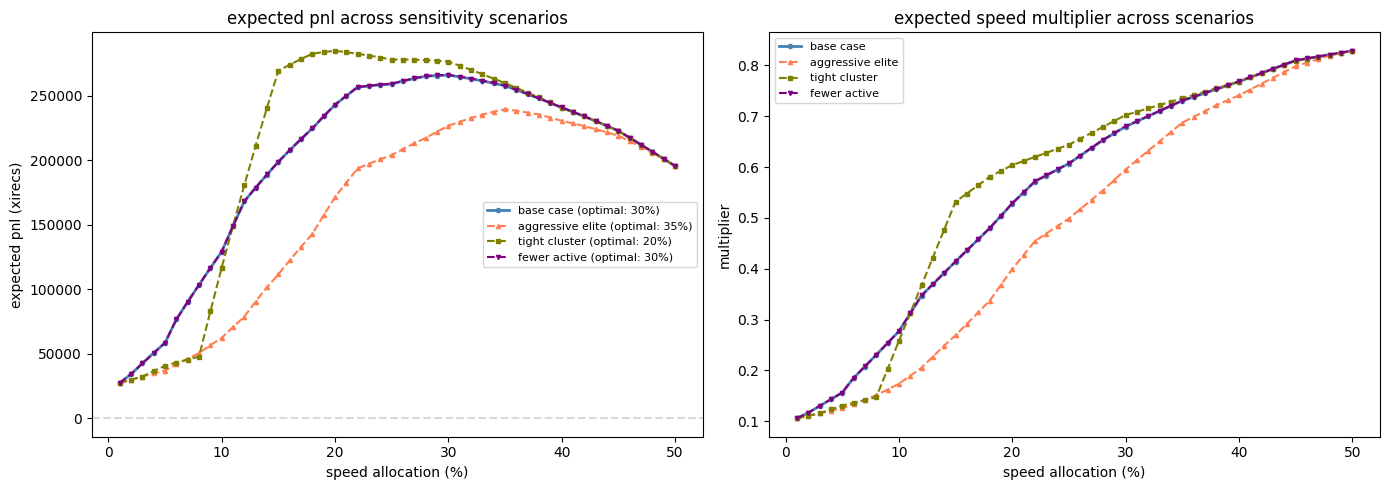

In [10]:
# sensitivity comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cands = results['candidates']

axes[0].plot(cands, results['e_pnl'], 'o-', color='steelblue', linewidth=2,
             markersize=3, label=f'base case (optimal: {best_sp}%)')
axes[0].plot(cands, res_agg['e_pnl'], '^--', color='coral', linewidth=1.5,
             markersize=3, label=f'aggressive elite (optimal: {res_agg["candidates"][best_agg]}%)')
axes[0].plot(cands, res_tight['e_pnl'], 's--', color='olive', linewidth=1.5,
             markersize=3, label=f'tight cluster (optimal: {res_tight["candidates"][best_tight]}%)')
axes[0].plot(cands, res_fewer['e_pnl'], 'v--', color='purple', linewidth=1.5,
             markersize=3, label=f'fewer active (optimal: {res_fewer["candidates"][best_fewer]}%)')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0].set_title('expected pnl across sensitivity scenarios')
axes[0].set_xlabel('speed allocation (%)')
axes[0].set_ylabel('expected pnl (xirecs)')
axes[0].legend(fontsize=8)

axes[1].plot(cands, results['e_mult'], 'o-', color='steelblue', linewidth=2,
             markersize=3, label='base case')
axes[1].plot(cands, res_agg['e_mult'], '^--', color='coral', linewidth=1.5,
             markersize=3, label='aggressive elite')
axes[1].plot(cands, res_tight['e_mult'], 's--', color='olive', linewidth=1.5,
             markersize=3, label='tight cluster')
axes[1].plot(cands, res_fewer['e_mult'], 'v--', color='purple', linewidth=1.5,
             markersize=3, label='fewer active')
axes[1].set_title('expected speed multiplier across scenarios')
axes[1].set_xlabel('speed allocation (%)')
axes[1].set_ylabel('multiplier')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 10. limitations, confidence, and final recommendation

**what we are confident about (high)**

the pnl formula has a clear structure that favours low-to-moderate speed allocation. the research function is logarithmic and saturates quickly: the first 20% of budget captures ~65% of maximum research value. scale is linear. together, the research*scale product declines smoothly as we divert budget to speed, losing about 1.3% per percentage point. the speed multiplier can at most be 0.9. these mathematical facts constrain the optimal allocation to lie well below 50% under any reasonable population model.

removing disengaged teams (78% of registered teams) from the active count is almost certainly correct. these teams submitted nothing for round 1 and are extremely unlikely to participate in round 2.

the empirical segmentation is grounded in observable data. a team that achieved exactly 87,995 in round 1 demonstrably ran an exhaustive optimization. a team that achieved 40,000-70,000 demonstrably did not.

**what we are moderately confident about (medium)**

the optimal solvers will cluster at relatively low speed allocations. the mathematical argument for low speed is straightforward: at any given multiplier, research*scale is maximized by minimizing speed. the question is how much game-theoretic depth they apply: do they simply minimize speed (risking the worst multiplier) or do they reason about what others will do and hedge upward?

the non-optimal and noise groups will allocate more broadly and higher. the word "speed" has competitive connotations that will attract over-allocation from teams that do not fully analyze the tradeoff. this is a well-documented behavioral bias: people overweight variables with competitive framing.

**what we are not confident about (low)**

the exact mixture weights and support intervals are heuristic. they are our best guesses about group behavior, but small changes in these parameters can shift the optimal allocation by 5-10 percentage points.

how many currently disengaged teams will participate in round 2. if thousands of previously inactive teams suddenly submit allocations, the rank distribution shifts unpredictably.

whether teams coordinate via discord or other channels. our model assumes independent decisions. if a popular strategy guide or discord post tells everyone to "put 10% in speed," we would see massive clustering that our model does not capture. the trembling-hand / weak perfect equilibrium reasoning partially mitigates this, but coordination effects could be large.

**bayesian game caveat.** our simulation computes a best response to our beliefs about the population. it does not compute a nash equilibrium. if many teams run similar analyses and converge on similar speed allocations, that creates a self-defeating prophecy: the "optimal" allocation becomes suboptimal because too many teams chose it, pushing down its rank. this is the fundamental limitation of any best-response approach in a simultaneous-move game with many players.

**the key uncertainty.** if the optimal solvers all go very low (say 5-10%), our optimal allocation is around 15-20%. if they spread out more (10-35%), our optimal is higher (25-35%). the sensitivity analysis brackets this range.

**bottom line.** across all scenarios tested, the optimal speed allocation ranges from roughly 15% to 35%, with our base case landing near the middle of this range. we recommend an allocation in this range, with the exact choice depending on one's beliefs about the optimal solvers' behavior.

In [11]:
# final summary
print("final recommendation summary")
print()

scenarios = [
    ("base case", best_sp, results['e_pnl'][best_idx], results['e_mult'][best_idx]),
    ("aggressive elite", res_agg['candidates'][best_agg],
     res_agg['e_pnl'][best_agg], res_agg['e_mult'][best_agg]),
    ("tight cluster", res_tight['candidates'][best_tight],
     res_tight['e_pnl'][best_tight], res_tight['e_mult'][best_tight]),
    ("fewer active", res_fewer['candidates'][best_fewer],
     res_fewer['e_pnl'][best_fewer], res_fewer['e_mult'][best_fewer]),
]

print(f"{'scenario':<22} {'optimal speed':>14} {'e[pnl]':>12} {'e[mult]':>8}")
for name, sp, pnl, mult in scenarios:
    print(f"{name:<22} {sp:>13}% {pnl:>12,.0f} {mult:>8.4f}")

print()
# full allocation for each scenario
for name, sp, pnl, mult in scenarios:
    r, s, _ = optimal_rs_product(sp)
    print(f"{name}: research={r:.1f}%, scale={s:.1f}%, speed={sp}%")

print()
print("across all scenarios, the optimal speed allocation falls in the")
range_lo = min(s[1] for s in scenarios)
range_hi = max(s[1] for s in scenarios)
print(f"{range_lo}% to {range_hi}% range.")

final recommendation summary

scenario                optimal speed       e[pnl]  e[mult]
base case                         30%      265,862   0.6797
aggressive elite                  35%      239,472   0.6873
tight cluster                     20%      284,776   0.6039
fewer active                      30%      266,032   0.6801

base case: research=17.2%, scale=52.8%, speed=30%
aggressive elite: research=16.2%, scale=48.8%, speed=35%
tight cluster: research=19.2%, scale=60.8%, speed=20%
fewer active: research=17.2%, scale=52.8%, speed=30%

across all scenarios, the optimal speed allocation falls in the
20% to 35% range.
